## Regresion lineal

#### Objetivo: ¿Qué regiones muestran costos mayores tras controlar por edad, BMI y número de hijos?


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
588,61,female,35.91,0,no,northeast,13635.6379
104,34,female,27.50,1,no,southwest,5003.8530
441,33,female,33.50,0,yes,southwest,37079.3720
940,18,male,23.21,0,no,southeast,1121.8739
880,22,male,34.80,3,no,southwest,3443.0640


In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

#### Cardinalidad y frecuencias de 'region'

In [7]:
df['region'].value_counts(dropna=False)

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

#### Rango y estadísticos de numéricas

In [12]:
print(df[['age','bmi','children','charges']].describe(percentiles=[.01,.05,.5,.95,.99]))

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
1%       18.000000    17.895150     0.000000   1252.972730
5%       18.000000    21.256000     0.000000   1757.753400
50%      39.000000    30.400000     1.000000   9382.033000
95%      62.000000    41.106000     3.000000  41181.827787
99%      64.000000    46.407900     5.000000  48537.480726
max      64.000000    53.130000     5.000000  63770.428010


#### Exploración dirigida al objetivo

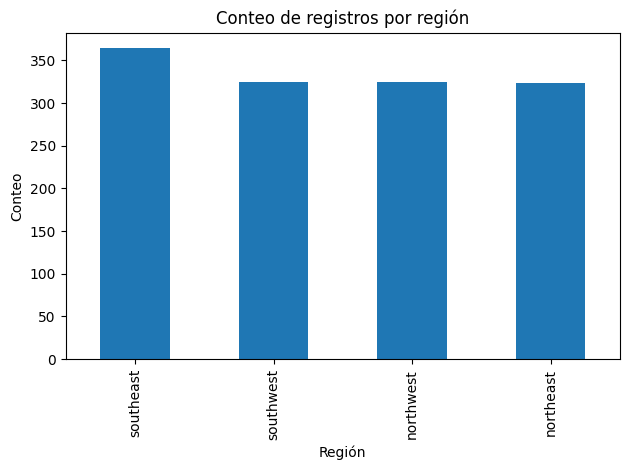

In [14]:
plt.figure()
df['region'].value_counts().plot(kind='bar')
plt.title("Conteo de registros por región")
plt.xlabel("Región")
plt.ylabel("Conteo")
plt.tight_layout()
plt.show()

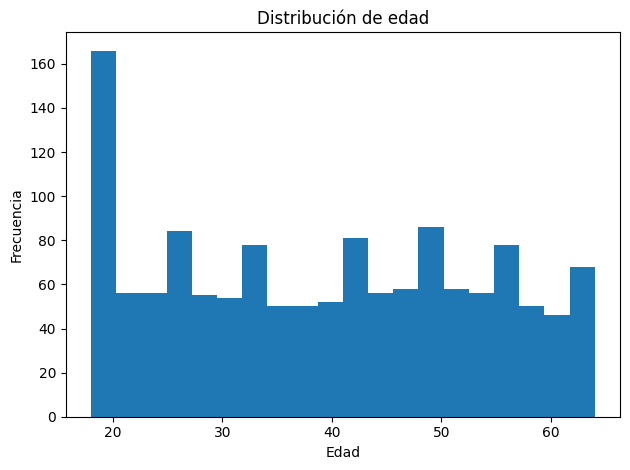

In [15]:
# Histograma de age
plt.figure()
plt.hist(df['age'], bins=20)
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

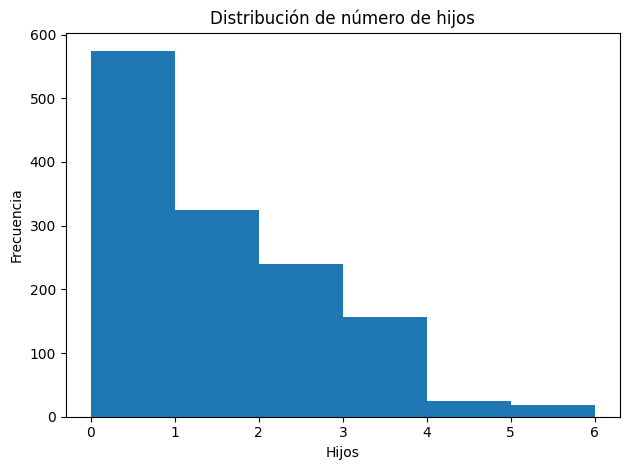

In [16]:
# Histograma de children
plt.figure()
plt.hist(df['children'], bins=range(int(df['children'].min()), int(df['children'].max())+2))
plt.title("Distribución de número de hijos")
plt.xlabel("Hijos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [17]:
# ==== 1.3 Distribución de charges y log(charges) ====
# Asimetría y curtosis
print("Skew(charges):", df['charges'].skew())
print("Kurtosis(charges):", df['charges'].kurt())

Skew(charges): 1.5158796580240388
Kurtosis(charges): 1.6062986532967907


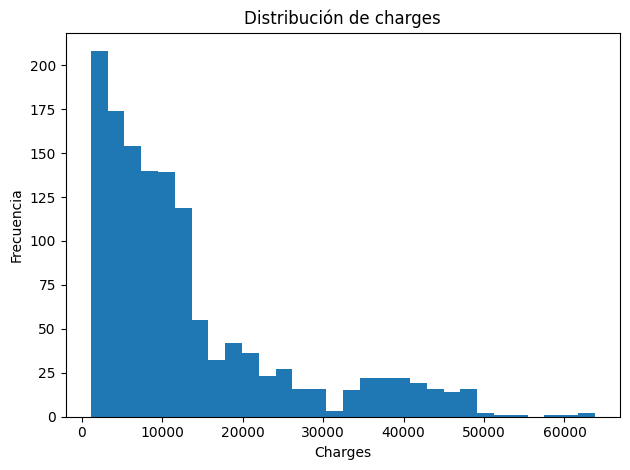

In [18]:
plt.figure()
plt.hist(df['charges'], bins=30)
plt.title("Distribución de charges")
plt.xlabel("Charges")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

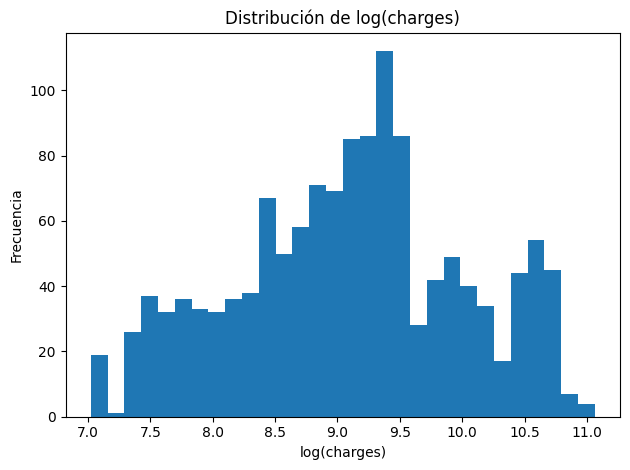

In [19]:
# Transformación log
df['log_charges'] = np.log(df['charges'])

plt.figure()
plt.hist(df['log_charges'], bins=30)
plt.title("Distribución de log(charges)")
plt.xlabel("log(charges)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

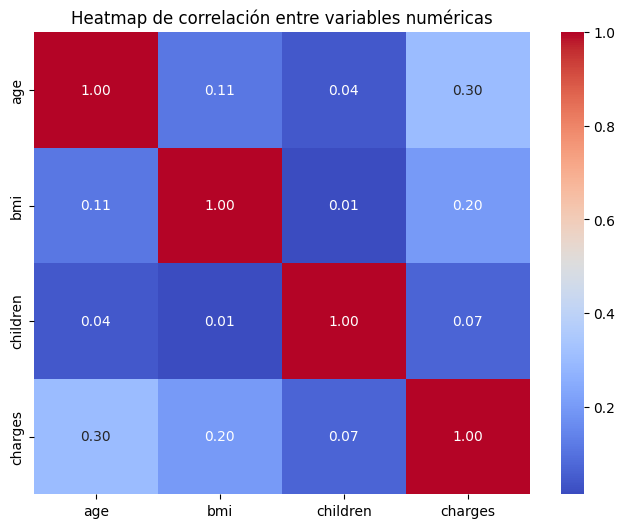

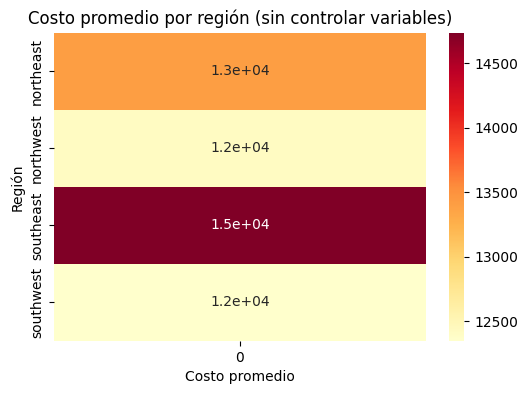

In [20]:
import seaborn as sns

# Agrupamos por región y calculamos el costo promedio ajustado por edad, bmi y children
pivot = df.pivot_table(
    index='region',
    values='charges',
    aggfunc='mean'
)

# Creamos una matriz de correlación para las variables relevantes
corr = df[['age', 'bmi', 'children', 'charges']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de correlación entre variables numéricas')
plt.show()

# Heatmap de costos promedio por región
plt.figure(figsize=(6, 4))
sns.heatmap(pivot.values.reshape(-1, 1), annot=True, cmap='YlOrRd', yticklabels=pivot.index)
plt.title('Costo promedio por región (sin controlar variables)')
plt.xlabel('Costo promedio')
plt.ylabel('Región')
plt.show()